@author: Octavio Gutiérrez de Código Máquina

URL del canal: https://www.youtube.com/CodigoMaquina

URL del video: https://youtu.be/NrIzhlXRJ70

# Análisis Formal de Cuestionarios Likert

# Módulos y configuración para visualización

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu
from scipy import stats
import matplotlib.pyplot as plt

etiquetas = [
    "Totalmente en desacuerdo",
    "En desacuerdo",
    "Neutral",
    "De acuerdo",
    "Totalmente de acuerdo"
]

paleta_de_colores = [
    "#6D2E46",  # Totalmente en desacuerdo
    "#B56576",  # En desacuerdo
    "#CFCFCF",  # Neutral
    "#6C9A8B",  # De acuerdo
    "#2F5D62"   # Totalmente de acuerdo
]

plt.style.use("default")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=paleta_de_colores)

# Respuestas a preguntas en escala Likert de 5 puntos

In [ ]:
# Respuestas a preguntas Likert del 1 (Total desacuerdo) al 5 (Total acuerdo)
respuestas_p1 = np.array([1, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 5, 4, 4, 4, 4])
respuestas_p2 = np.array([2, 2, 3, 2, 3, 3, 3, 3, 3, 4, 4, 4, 2, 4, 3, 3, 3, 4, 1])

# Estadística básica

In [ ]:
# Medidas básicas
media = np.mean(respuestas_p1)
mediana = np.median(respuestas_p1)
moda = stats.mode(respuestas_p1, keepdims=True)[0][0]
desv_std = np.std(respuestas_p1, ddof=1)  # desviación estándar muestral
varianza = np.var(respuestas_p1, ddof=1)
minimo = np.min(respuestas_p1)
maximo = np.max(respuestas_p1)
rango = maximo - minimo

# Cuartiles
q1 = np.percentile(respuestas_p1, 25)
q3 = np.percentile(respuestas_p1, 75)
iqr = q3 - q1

# Mostrar resultados
print("Estadística descriptiva básica")
print("-" * 40)
print(f"n: {len(respuestas_p1)}")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")
print(f"Desviación estándar: {desv_std:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")
print(f"Rango: {rango}")
print(f"Q1 (25%): {q1}")
print(f"Q3 (75%): {q3}")
print(f"Rango intercuartílico (IQR): {iqr}")

Estadística descriptiva básica
----------------------------------------
n: 19
Media: 3.16
Mediana: 3.0
Moda: 3
Desviación estándar: 0.96
Varianza: 0.92
Mínimo: 1
Máximo: 5
Rango: 4
Q1 (25%): 3.0
Q3 (75%): 4.0
Rango intercuartílico (IQR): 1.0


# Barras Divergentes para Escala Likert

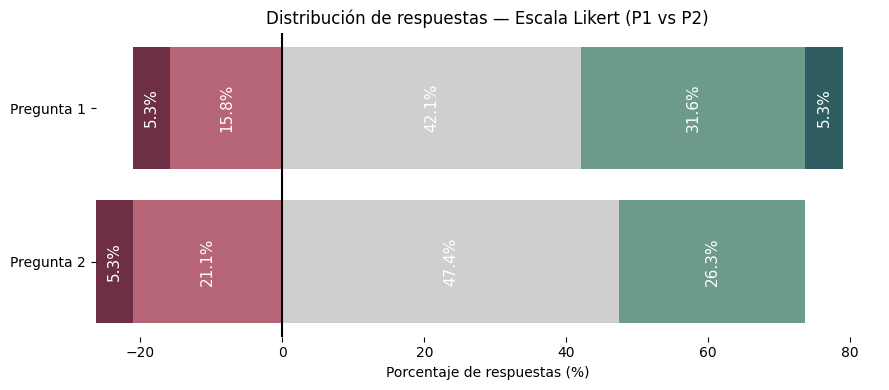

In [ ]:
# Función para calcular porcentajes por categoría
def calcular_porcentajes_likert(datos):
    niveles = np.arange(1, 6)
    conteos = np.array([(datos == i).sum() for i in niveles])
    porcentajes = conteos / conteos.sum() * 100
    return porcentajes

# Cálculo de porcentajes para cada pregunta
porcentajes_p1 = calcular_porcentajes_likert(respuestas_p1)
porcentajes_p2 = calcular_porcentajes_likert(respuestas_p2)

# Crear figura
fig, ax = plt.subplots(figsize=(9, 4))

# Función para graficar barra divergente con etiquetas
def graficar_barra_divergente(fila, etiqueta_y):
    negativos = fila[:2]   # 1 y 2
    neutral = fila[2]      # 3
    positivos = fila[3:]   # 4 y 5

    # Lado negativo (izquierda)
    posicion_izquierda = -sum(negativos)
    for valor in negativos:
        barra = ax.barh(etiqueta_y, valor, left=posicion_izquierda)

        if valor > 3:  # evitar texto en segmentos muy pequeños
            ax.text(
                posicion_izquierda + valor / 2,
                etiqueta_y,
                f"{valor:.1f}%",
                ha="center",
                va="center",
                rotation=90,
                color="white",
                fontsize=11
            )
        posicion_izquierda += valor

    # Neutral
    barra = ax.barh(etiqueta_y, neutral, left=0)
    if neutral > 3:
        ax.text(
            neutral / 2,
            etiqueta_y,
            f"{neutral:.1f}%",
            ha="center",
            va="center",
            rotation=90,
            color="white",
            fontsize=11
        )

    # Lado positivo (derecha)
    posicion_derecha = neutral
    for valor in positivos:
        barra = ax.barh(etiqueta_y, valor, left=posicion_derecha)

        if valor > 3:
            ax.text(
                posicion_derecha + valor / 2,
                etiqueta_y,
                f"{valor:.1f}%",
                ha="center",
                va="center",
                rotation=90,
                color="white",
                fontsize=11
            )
        posicion_derecha += valor


# Graficar ambas preguntas
graficar_barra_divergente(porcentajes_p2, "Pregunta 2")
graficar_barra_divergente(porcentajes_p1, "Pregunta 1")

# Línea central
ax.axvline(0, color="black")

# Etiquetas y título
ax.set_xlabel("Porcentaje de respuestas (%)")
ax.set_title("Distribución de respuestas — Escala Likert (P1 vs P2)")

plt.box(False)
plt.tight_layout()
plt.savefig("apilado1.png", dpi=300, transparent=True)
plt.show()

# Distribución de Respuestas con Barras Apiladas (100%)

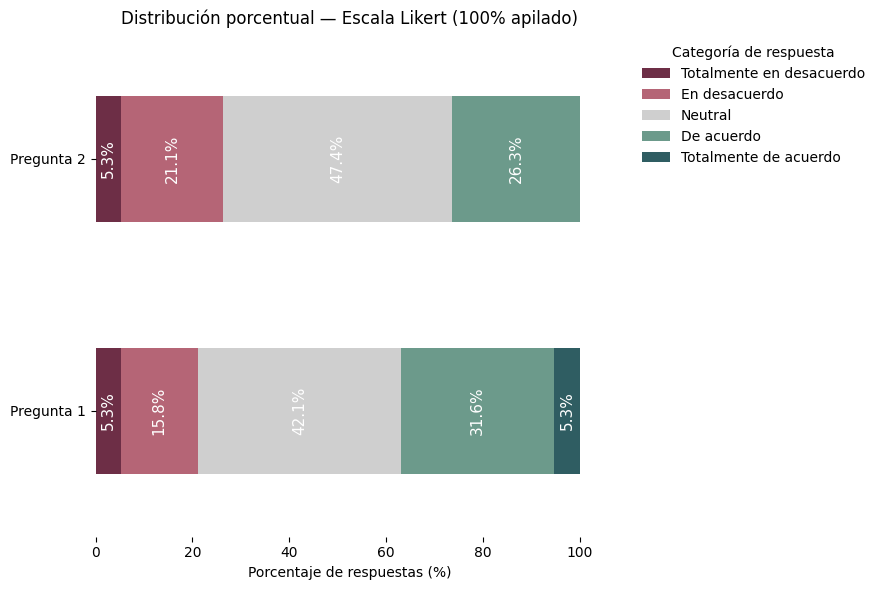

In [ ]:
# Calcular porcentajes
porcentajes_p1 = calcular_porcentajes_likert(respuestas_p1)
porcentajes_p2 = calcular_porcentajes_likert(respuestas_p2)

# Crear DataFrame con porcentajes
df = pd.DataFrame(
    {
        "Pregunta 1": porcentajes_p1,
        "Pregunta 2": porcentajes_p2
    },
    index=etiquetas
)

# Gráfico de barras horizontales apiladas (100%)
ax = df.T.plot(
    kind="barh",
    stacked=True,
    figsize=(9, 6)
)

# ---- Añadir etiquetas de porcentaje ----
for container in ax.containers:
    for bar in container:
        ancho = bar.get_width()
        if ancho > 3:  # evitar etiquetas en segmentos muy pequeños
            ax.text(
                bar.get_x() + ancho / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{ancho:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=11,
                rotation=90
            )

# Configuración estética
ax.set_xlabel("Porcentaje de respuestas (%)")
ax.set_title("Distribución porcentual — Escala Likert (100% apilado)")
ax.legend(title="Categoría de respuesta", bbox_to_anchor=(1.05, 1), frameon=False)

plt.box(False)
plt.tight_layout()
plt.savefig("apilado2.png", dpi=300, transparent=True)
plt.show()

# Distribución de Respuestas con Diagramas de Caja

/tmp/ipython-input-2440025643.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


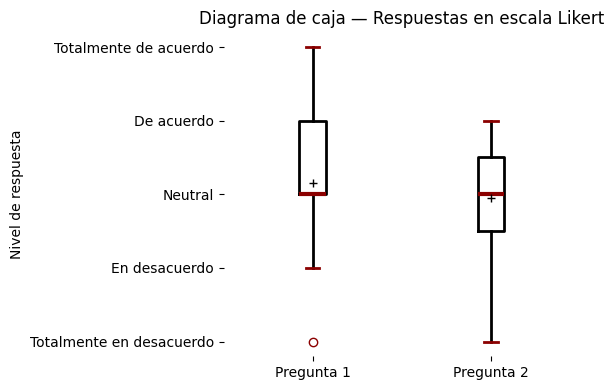

In [ ]:
# Datos a comparar
datos = [respuestas_p1, respuestas_p2]

# Propiedades visuales
propiedades_mediana = dict(linestyle='-', linewidth=3, color='#8B0000')
propiedades_caja = dict(linestyle='-', linewidth=2)
propiedades_topes = dict(linestyle='-', linewidth=2, color='#8B0000')
propiedades_bigotes = dict(linestyle='-', linewidth=2)
propiedades_media = dict(marker='+', markerfacecolor='black', markeredgecolor='black')
propiedades_atipicos = dict(marker='o', markeredgecolor='#8B0000', markersize=6)

# Crear figura
plt.figure(figsize=(6, 4))

plt.boxplot(
    datos,
    labels=["Pregunta 1", "Pregunta 2"],
    showmeans=True,
    medianprops=propiedades_mediana,
    boxprops=propiedades_caja,
    capprops=propiedades_topes,
    whiskerprops=propiedades_bigotes,
    meanprops=propiedades_media,
    flierprops=propiedades_atipicos
)

# Configuración de ejes
plt.yticks([1, 2, 3, 4, 5], etiquetas)
plt.title("Diagrama de caja — Respuestas en escala Likert")
plt.ylabel("Nivel de respuesta")

plt.box(False)
plt.tight_layout()
plt.savefig("caja.png", dpi=300, transparent=True)
plt.show()

# Distribución de Respuestas con Pasteles



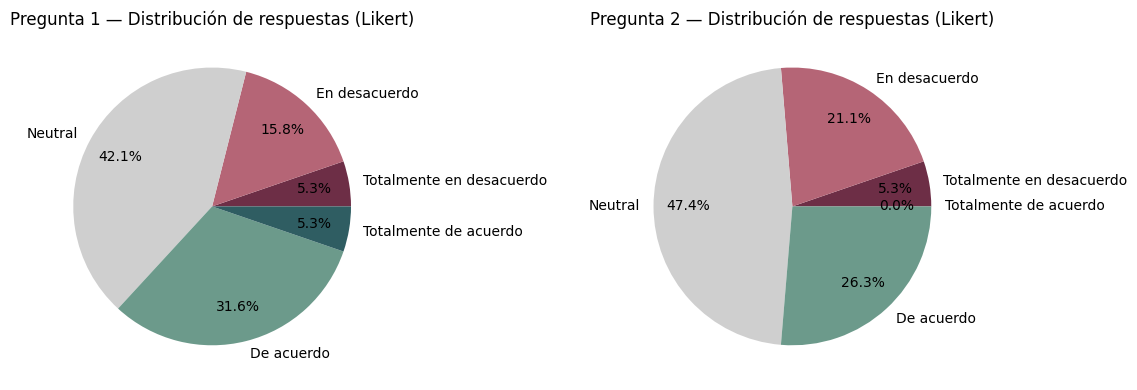

In [ ]:
# Niveles de la escala Likert (1 a 5)
niveles = np.arange(1, 6)

# Función para calcular frecuencias absolutas
def calcular_frecuencias_likert(datos):
    return [(datos == i).sum() for i in niveles]

# Cálculo de frecuencias
frecuencias_p1 = calcular_frecuencias_likert(respuestas_p1)
frecuencias_p2 = calcular_frecuencias_likert(respuestas_p2)

# Crear figura con dos gráficos
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico para Pregunta 1
ejes[0].pie(
    frecuencias_p1,
    labels=etiquetas,
    autopct="%1.1f%%",
    startangle=0,
    labeldistance=1.1,
    pctdistance=0.75
)
ejes[0].set_title("Pregunta 1 — Distribución de respuestas (Likert)")

# Gráfico para Pregunta 2
ejes[1].pie(
    frecuencias_p2,
    labels=etiquetas,
    autopct="%1.1f%%",
    startangle=0,
    labeldistance=1.1,
    pctdistance=0.75
)
ejes[1].set_title("Pregunta 2 — Distribución de respuestas (Likert)")
plt.savefig("pie1.png", dpi=300, transparent=True)
plt.tight_layout()
plt.show()

# Presentar Gráficas de Pasteles: Satisfecho vs Insatisfecho

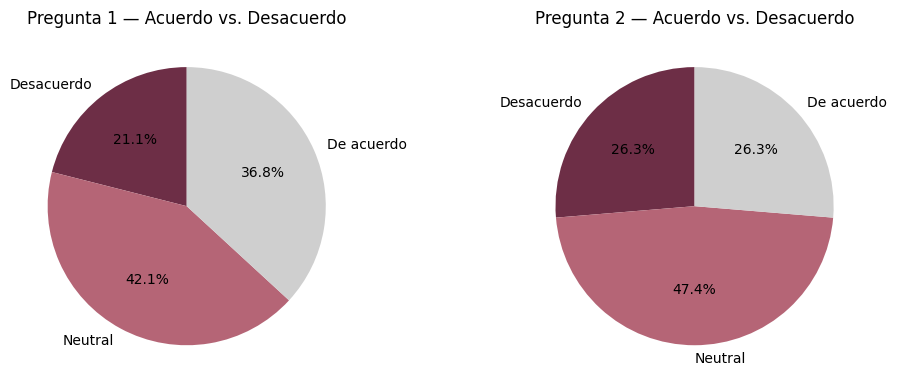

In [ ]:
# Función para agrupar respuestas Likert en tres categorías:
# 1-2 = Desacuerdo | 3 = Neutral | 4-5 = De acuerdo
def agrupar_likert(datos):
    total_desacuerdo = np.sum((datos == 1) | (datos == 2))
    total_neutral = np.sum(datos == 3)
    total_acuerdo = np.sum((datos == 4) | (datos == 5))
    return [total_desacuerdo, total_neutral, total_acuerdo]

# Etiquetas de las categorías
etiquetas = ["Desacuerdo", "Neutral", "De acuerdo"]

# Cálculo para cada pregunta
valores_p1 = agrupar_likert(respuestas_p1)
valores_p2 = agrupar_likert(respuestas_p2)

# Crear figura con dos gráficos
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico para Pregunta 1
ejes[0].pie(
    valores_p1,
    labels=etiquetas,
    autopct="%1.1f%%",
    startangle=90
)
ejes[0].set_title("Pregunta 1 — Acuerdo vs. Desacuerdo")

# Gráfico para Pregunta 2
ejes[1].pie(
    valores_p2,
    labels=etiquetas,
    autopct="%1.1f%%",
    startangle=90
)
ejes[1].set_title("Pregunta 2 — Acuerdo vs. Desacuerdo")
plt.savefig("pie2.png", dpi=300, transparent=True)
plt.tight_layout()
plt.show()

# Reportar los Intervalos de Confianza (IC)

In [ ]:
# Función bootstrap para la mediana
def bootstrap_ic_mediana(datos, n_bootstrap=10000, alpha=0.05):
    np.random.seed(42)  # reproducibilidad
    n = len(datos)
    estimaciones = []

    for _ in range(n_bootstrap):
        muestra = np.random.choice(datos, size=n, replace=True)
        estimaciones.append(np.median(muestra))

    li = np.percentile(estimaciones, 100 * (alpha / 2))
    ls = np.percentile(estimaciones, 100 * (1 - alpha / 2))

    return np.median(datos), li, ls

# Calcular intervalos
mediana_p1, li_p1, ls_p1 = bootstrap_ic_mediana(respuestas_p1)
mediana_p2, li_p2, ls_p2 = bootstrap_ic_mediana(respuestas_p2)

# Mostrar resultados
print("Intervalos de confianza (95%) para la mediana — Bootstrap")
print("-" * 60)
print(f"Pregunta 1: Mediana = {mediana_p1}")
print(f"IC 95%: [{li_p1:.2f}, {ls_p1:.2f}]\n")

print(f"Pregunta 2: Mediana = {mediana_p2}")
print(f"IC 95%: [{li_p2:.2f}, {ls_p2:.2f}]")

Intervalos de confianza (95%) para la mediana — Bootstrap
------------------------------------------------------------
Pregunta 1: Mediana = 3.0
IC 95%: [3.00, 4.00]

Pregunta 2: Mediana = 3.0
IC 95%: [3.00, 3.00]


# Reportar los Rangos Intercuantílicos (RIC)

In [ ]:
# Calcular cuantiles y Rango Intercuantílico (RIC)
def calcular_ric(datos):
    q1 = np.percentile(datos, 25)
    q3 = np.percentile(datos, 75)
    ric = q3 - q1
    return q1, q3, ric, np.median(datos)

q1_p1, q3_p1, ric_p1, mediana_p1 = calcular_ric(respuestas_p1)
q1_p2, q3_p2, ric_p2, mediana_p2 = calcular_ric(respuestas_p2)

print("Rango intercuartílico (RIC)")
print("-" * 40)

print("Pregunta 1:")
print(f"Mediana = {mediana_p1}")
print(f"Q1 = {q1_p1}")
print(f"Q3 = {q3_p1}")
print(f"RIC = {ric_p1}\n")

print("Pregunta 2:")
print(f"Mediana = {mediana_p2}")
print(f"Q1 = {q1_p2}")
print(f"Q3 = {q3_p2}")
print(f"RIC = {ric_p2}")

Rango intercuartílico (RIC)
----------------------------------------
Pregunta 1:
Mediana = 3.0
Q1 = 3.0
Q3 = 4.0
RIC = 1.0

Pregunta 2:
Mediana = 3.0
Q1 = 2.5
Q3 = 3.5
RIC = 1.0


# Prueba de rangos con signo de Wilcoxon para una muestra
## Evaluar si la mediana difiere significativamente de un valor de referencia

In [ ]:
# Valor de referencia (k)
mediana_p1 = np.median(respuestas_p1)
k = mediana_p1 - 1

# Prueba de Wilcoxon
stat, p = wilcoxon(respuestas_p1 - k, alternative="greater")

# Resultados
print("Prueba de rangos con signo de Wilcoxon")
print("-" * 45)
print(f"Mediana observada: {mediana_p1}")
print(f"Valor de referencia (k): {k}")
print(f"Estadístico W: {stat:.3f}")
print(f"Valor p: {p:.4f}")

# Nivel de significancia
alpha = 0.05

print("\nNivel de significancia α = 0.05:")
if p < alpha:
    print("Se rechaza H0 → La mediana es significativamente mayor que k.")
else:
    print("No se rechaza H0 → No hay evidencia suficiente para afirmar que la mediana sea mayor que k.")

Prueba de rangos con signo de Wilcoxon
---------------------------------------------
Mediana observada: 3.0
Valor de referencia (k): 2.0
Estadístico W: 131.000
Valor p: 0.0004

Nivel de significancia α = 0.05:
Se rechaza H0 → La mediana es significativamente mayor que k.


# Prueba U de Mann–Whitney para muestras independiente
## Comparar las respuestas en escala Likert entre grupos, asumiendo que:
* Los participantes de un grupo no están relacionados con los del otro.
* Las observaciones son independientes.

In [ ]:
import numpy as np

# Datos
respuestas_p1_grupo_a = np.array([2, 2, 3, 2, 2, 3, 1, 3, 1, 4, 4, 4, 2, 4, 3, 3, 3, 4, 1])
respuestas_p1_grupo_b = np.array([5, 2, 5, 5, 5, 3, 5, 5, 3, 5, 4, 5, 4, 4, 5, 4, 4, 4, 4])

# Medianas
mediana_a = np.median(respuestas_p1_grupo_a)
mediana_b = np.median(respuestas_p1_grupo_b)

# Prueba U de Mann–Whitney (grupos independientes)
stat, p = mannwhitneyu(respuestas_p1_grupo_a,
                       respuestas_p1_grupo_b,
                       alternative="two-sided")

# Resultados
print("Prueba U de Mann–Whitney (grupos independientes)")
print("-" * 60)
print(f"Mediana Grupo A: {mediana_a}")
print(f"Mediana Grupo B: {mediana_b}")
print(f"Estadístico U: {stat:.3f}")
print(f"Valor p: {p:.4f}")

# Nivel de significancia
alpha = 0.05

print("\nNivel de significancia α = 0.05:")
if p < alpha:
    print("Se rechaza H0 → Existe diferencia significativa entre los grupos.")
else:
    print("No se rechaza H0 → No se observa diferencia significativa entre los grupos.")

Prueba U de Mann–Whitney (grupos independientes)
------------------------------------------------------------
Mediana Grupo A: 3.0
Mediana Grupo B: 4.0
Estadístico U: 47.000
Valor p: 0.0001

Nivel de significancia α = 0.05:
Se rechaza H0 → Existe diferencia significativa entre los grupos.
